# Исследование данных сервиса самокатов GoFast

В нашем распоряжении данные сервиса самокатов GoFast о некоторых пользователях из нескольких городов, а также об их поездках. Нам необходимо проанализировать данные и проверить некоторые гипотезы, которые могут помочь бизнесу вырасти.

В частности, нам важно понять, тратят ли пользователи с подпиской больше времени на поездки? Если да, то пользователи с подпиской могут быть «выгоднее» для компании. 

Также нам важно, не превышает ли среднее расстояние за одну поездку 3130 метров? Если да, то это не очень хорошо сказывается на износе самоката.

И конечно нам важно понять, выше ли помесячная выручка от пользователей с подпиской по месяцам, чем выручка от пользователей без подписки. Это нам даст повод, стоит ли менять условие подписки или менять условие для пользователей без подписки.

Чтобы решить поставленный вопрос, нам нужно сделать следующее:
1. Изучить и предобработать данные
2. Провести исследовательских анализ данных
3. Объединить таблицы и получить общий датафрейм
4. Посчитать ежемесячную выручку
5. Проверить несколько гипотез

## Загрузка данных

Импортируем необходимые библиотеки для дальнейшей работы.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats as st
from math import factorial, exp, sqrt

Откроем три csv-файла и сохраним их в датафреймы под соответствующими названиями. Проверим корректность чтения, выведя первые 5 строк каждой таблицы.

In [2]:
data_users = pd.read_csv('/datasets/users_go.csv')
data_rides = pd.read_csv('/datasets/rides_go.csv')
data_subscription = pd.read_csv('/datasets/subscriptions_go.csv')
print(data_users.head())
print(data_rides.head())
data_subscription.head()

   user_id        name  age            city subscription_type
0        1        Кира   22          Тюмень             ultra
1        2   Станислав   31            Омск             ultra
2        3     Алексей   20          Москва             ultra
3        4  Константин   26  Ростов-на-Дону             ultra
4        5       Адель   28            Омск             ultra
   user_id     distance   duration        date
0        1  4409.919140  25.599769  2021-01-01
1        1  2617.592153  15.816871  2021-01-18
2        1   754.159807   6.232113  2021-04-20
3        1  2694.783254  18.511000  2021-08-11
4        1  4028.687306  26.265803  2021-08-28


,subscription_type,minute_price,start_ride_price,subscription_fee
0,free,8,50,0
1,ultra,6,0,199


Все открылось корректно, проблем нет.

Изучим общую информацию таблиц users_go.csv и rides_go.csv. Изучать общую информацию subscriptions_go.csv нет смысла, это информация о деталях подписки.

In [3]:
print(data_users.info())
data_rides.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1565 entries, 0 to 1564
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   user_id            1565 non-null   int64 
 1   name               1565 non-null   object
 2   age                1565 non-null   int64 
 3   city               1565 non-null   object
 4   subscription_type  1565 non-null   object
dtypes: int64(2), object(3)
memory usage: 61.3+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18068 entries, 0 to 18067
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   user_id   18068 non-null  int64  
 1   distance  18068 non-null  float64
 2   duration  18068 non-null  float64
 3   date      18068 non-null  object 
dtypes: float64(2), int64(1), object(1)
memory usage: 564.8+ KB


Судя по всему пропусков нигде нету, это мы проверим далее. Можно предположить, что в таблице rides_go будут несколько раз встречаться одинаковые user_id из-за большего количества строк. Это просто значит, что на каждого пользователя может быть несколько строк касаемо его поездок. 

## Предобработка данных

Будем последовательно предобрабатывать данные в таблицах data_users и data_rides. В таблице data_subscription очевидно пропусков нет, это информация о деталях подписки.

### Предобработка данных таблицы data_users

Проверим пропуски.

In [4]:
data_users.isna().sum()

user_id              0
name                 0
age                  0
city                 0
subscription_type    0
dtype: int64

Пропусков нету, как и предполагалось. Отлично.

Проверим явные дубликаты.

In [5]:
data_users.duplicated().sum()

31

Дубликаты есть. Удаляем. Переустановим индексы для удобства. Проверим, что 31 строки действительно удалились.

In [6]:
data_users = data_users.drop_duplicates().reset_index(drop=True)
data_users.shape[0]

1534

Все отлично.

Согласно логике, неявных дубликатов пользователей тут не будет, поскольку уникальность пользователя определяется столбцом user_id. Проверим. что user_id действительно все разные.

In [7]:
data_users['user_id'].duplicated().sum()

0

Проверим столбец age на наличие аномальных значений.

In [8]:
data_users['age'].describe()

count    1534.000000
mean       24.903520
std         4.572367
min        12.000000
25%        22.000000
50%        25.000000
75%        28.000000
max        43.000000
Name: age, dtype: float64

Все выглядит адекватно. Насколько известно, по условиям не было ограничения возраста для аренды самоката, поэтому 12 лет тоже адекватное значение.

И последнее. Посмотрим, что в названиях городов нету одинаковых городов с буквами е и ё. Если есть - заменим.

In [9]:
data_users['city'].unique()

array(['Тюмень', 'Омск', 'Москва', 'Ростов-на-Дону', 'Краснодар',
       'Пятигорск', 'Екатеринбург', 'Сочи'], dtype=object)

Всё отлично. На этом с таблицей data_users всё. Самое главное - убрали дубликаты.

### Предобработка данных таблицы data_rides

Проверим пропуски.

In [10]:
data_rides.isna().sum()

user_id     0
distance    0
duration    0
date        0
dtype: int64

Пропусков нету, как и предполагалось. Отлично.

Проверим явные дубликаты, вдруг информация об одной поездке записалась дважды. Неявных дубликатов, согласно логике, тут не может быть.

In [11]:
data_rides.duplicated().sum()

0

Дубликатов нет, отлично.

Проверим столбец distance на наличие аномальных значений. 

In [12]:
data_rides['distance'].describe()

count    18068.000000
mean      3070.659976
std       1116.831209
min          0.855683
25%       2543.226360
50%       3133.609994
75%       3776.222735
max       7211.007745
Name: distance, dtype: float64

Как видим, у нас есть аномально маленькое значение в 0.85 метров и максимальное значение в 7211 метров. Маленькое значение можно назвать выбросом, скорее всего пользователь начал поездку и сразу завершил, такие значения нам испортят исследования. А вот максимальное значение вряд ли можно назвать выбросом с логической точки зрения, пользователь действительно мог проехать около 7 км. Построим boxplot и более наглядно посмотрим на выбросы.

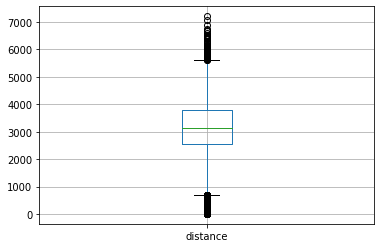

In [13]:
data_rides.boxplot(column='distance')
plt.show()

Как видим, у нас достаточно много значений, что выходят за 1.5 квартильного размаха от первого и третьего квартиля. Согласно теории, мы должны считать выбросами все значения, что меньше 693 и больше 5625 метров соответственно. Но согласно логике максимальное расстояние в 7км кажется адекватным, поэтому не будем считать выбросы те значения, что выше 5625 метров. Но в данном случае удалять данные мы не будем, поскольку за эти поездки могла начисляться плата и удаление этих данных может исказить подсчет выручки.

Потеряли около 500 данных, это примерно 2.7% от выборки. Не критично.

Проверим столбец duration на наличие аномальных значений. 

In [14]:
data_rides['duration'].describe()

count    18068.000000
mean        17.805011
std          6.091051
min          0.500000
25%         13.597563
50%         17.678395
75%         21.724800
max         40.823963
Name: duration, dtype: float64

Максимальное значение в норме, 40 минут адекватное значение, а вот минимальное значение в пол минуты выброс. Построим boxlplot для визуализации выбросов.

<AxesSubplot:>

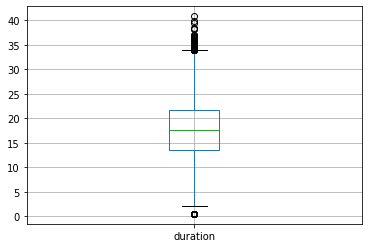

In [15]:
data_rides.boxplot(column='duration')

По графику видно, что значения меньше 3 минут считаются выбросами, но удалять их не будем, поскольку за начало поездки у определенной категории пользователей уже может сниматься плата, поэтому эти данные стоит учитывать.

Потеряли всего около 90 строчек, избавились от выбросов. 

Преобразуем столбец date в формат datetime для удобной работы.

In [16]:
data_rides['date'] = pd.to_datetime(data_rides['date'], format='%Y-%m-%d')
data_rides.dtypes

user_id              int64
distance           float64
duration           float64
date        datetime64[ns]
dtype: object

Создадим новый столбец month с номером месяца.

In [17]:
data_rides['month'] = data_rides['date'].dt.month
data_rides.head()

,user_id,distance,duration,date,month
0,1,4409.919140,25.599769,2021-01-01,1
1,1,2617.592153,15.816871,2021-01-18,1
2,1,754.159807,6.232113,2021-04-20,4
3,1,2694.783254,18.511000,2021-08-11,8
4,1,4028.687306,26.265803,2021-08-28,8


**Вывод:**
- Избавились от дубликатов в датафрейме data_users
- Преобразовали столбец data к типу datetime и создали новый столбец с номером месяца в data_rides_clear

## Исследовательский анализ данных

### Частота встречаемости городов

Проанализируем общеее количество пользователей для каждого города. Построим столбчатую диаграмму с количество пользователей для каждого города.

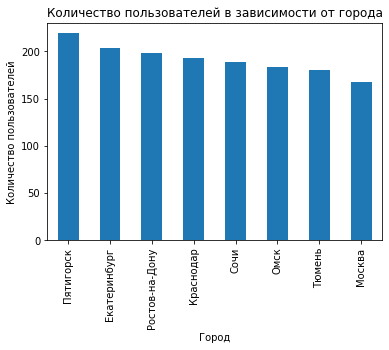

Пятигорск         219
Екатеринбург      204
Ростов-на-Дону    198
Краснодар         193
Сочи              189
Омск              183
Тюмень            180
Москва            168
Name: city, dtype: int64

In [18]:
data_users['city'].value_counts().plot(kind='bar')
plt.title('Количество пользователей в зависимости от города')
plt.xlabel('Город')
plt.ylabel('Количество пользователей')
plt.show()
data_users['city'].value_counts()

Больше всего пользователей в Пятигорске, меньше всего в Москве.

### Cоотношение пользователей с подпиской и без подписки

Проанализируем количество пользователей с подпиской и без. Построим столбчатую диаграмму.

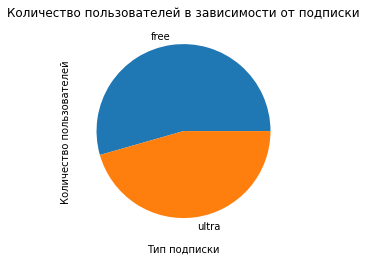

free     835
ultra    699
Name: subscription_type, dtype: int64

In [19]:
data_users['subscription_type'].value_counts().plot(kind='pie')
plt.title('Количество пользователей в зависимости от подписки')
plt.xlabel('Тип подписки')
plt.ylabel('Количество пользователей')
plt.show()
data_users['subscription_type'].value_counts()

Количество пользователей без подписки выше, но разница невысокая (835 без подписки и 699 с подпиской).

### Возраст пользователей

Проанализируем количество пользователей по возрасту. Построим гистограмму.

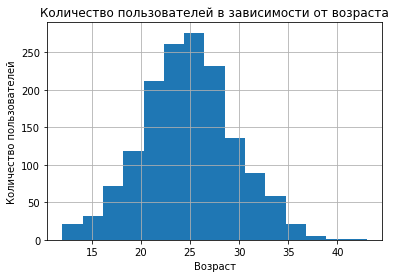

25    145
24    132
26    131
23    129
27    119
Name: age, dtype: int64


count    1534.000000
mean       24.903520
std         4.572367
min        12.000000
25%        22.000000
50%        25.000000
75%        28.000000
max        43.000000
Name: age, dtype: float64

In [20]:
data_users['age'].hist(bins=15)
plt.title('Количество пользователей в зависимости от возраста')
plt.xlabel('Возраст')
plt.ylabel('Количество пользователей')
plt.show()
print(data_users['age'].value_counts().head())
data_users['age'].describe()

Как видно, пользователей в возрасте 23-27 лет наибольшее количество. Наименьшее же количество наблюдается у людей с возрастом 35+ и не так много пользователей младше 14 лет. Судя по тому, что медиана и среднее практически равны, то сильных выбросов у нас не наблюдается, это можно заметить также по минимальному и максимальному значению в этом столбце.

### Расстояние, которое пользователь преодолел за одну поездку

Проанализируем расстояние, которое пользователь преодолел за одну поездку. Построим гистограмму.

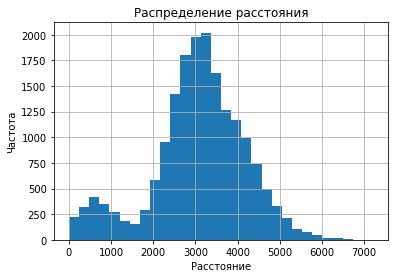

In [21]:
data_rides['distance'].hist(bins=30)
plt.title('Распределение расстояния')
plt.xlabel('Расстояние')
plt.ylabel('Частота')
plt.show()

Как видно, расстояние в среднем равно в районе 3000 метров. Все достаточно логично. 

### Продолжительность поездок

Проанализируем продолжительность поездок. Построим гистограмму.

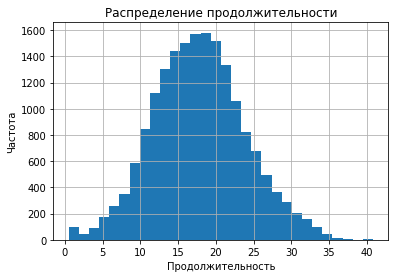

In [22]:
data_rides['duration'].hist(bins=30)
plt.title('Распределение продолжительности')
plt.xlabel('Продолжительность')
plt.ylabel('Частота')
plt.show()

В среднем продолжительность за одну поездку равна 15-20 минут.

**ВЫВОД:**
- Больше всего пользователей в Пятигорске, меньше всего в Москве
- Количество пользователей без подписки выше, но разница невысокая
- Наибольшее количество пользователей в районе 23-27 лет 
- Расстояние в среднем за одну поездку равно 3000 метров
- В среднем продолжительность за одну поездку равна 15-20 минут

## Объединение данных

Объединим данные методом merge. Посмотрим, что все правильно объединилось и посмотрим на количество строк (ничего ли не потеряли).

In [23]:
data_total = data_users.merge(data_rides)
print(data_total.head())
data_total.shape[0]

   user_id  name  age    city subscription_type     distance   duration  \
0        1  Кира   22  Тюмень             ultra  4409.919140  25.599769   
1        1  Кира   22  Тюмень             ultra  2617.592153  15.816871   
2        1  Кира   22  Тюмень             ultra   754.159807   6.232113   
3        1  Кира   22  Тюмень             ultra  2694.783254  18.511000   
4        1  Кира   22  Тюмень             ultra  4028.687306  26.265803   

        date  month  
0 2021-01-01      1  
1 2021-01-18      1  
2 2021-04-20      4  
3 2021-08-11      8  
4 2021-08-28      8  


18068

Все отлично.

Создадим ещё два датафрейма из датафрейма, созданного на этапе 4.1: c данными о пользователях без подписки; с данными о пользователях с подпиской. Проверим корректность создания.

In [24]:
data_free = data_total.query('subscription_type=="free"')
data_ultra = data_total.query('subscription_type=="ultra"')
print(data_free.head())
data_ultra.head()

      user_id   name  age  city subscription_type     distance   duration  \
6500      700  Айдар   22  Омск              free  2515.690719  14.944286   
6501      700  Айдар   22  Омск              free   846.932642  16.234663   
6502      700  Айдар   22  Омск              free  4004.434142  20.016628   
6503      700  Айдар   22  Омск              free  1205.911290   9.782872   
6504      700  Айдар   22  Омск              free  3047.379435  17.427673   

           date  month  
6500 2021-01-02      1  
6501 2021-02-01      2  
6502 2021-02-04      2  
6503 2021-02-10      2  
6504 2021-02-14      2  


,user_id,name,age,city,subscription_type,distance,duration,date,month
0,1,Кира,22,Тюмень,ultra,4409.919140,25.599769,2021-01-01,1
1,1,Кира,22,Тюмень,ultra,2617.592153,15.816871,2021-01-18,1
2,1,Кира,22,Тюмень,ultra,754.159807,6.232113,2021-04-20,4
3,1,Кира,22,Тюмень,ultra,2694.783254,18.511000,2021-08-11,8
4,1,Кира,22,Тюмень,ultra,4028.687306,26.265803,2021-08-28,8


Все создалось согласно условиям.

### Визуализация информациюи о расстоянии и времени поездок для пользователей обеих категорий

Построим гистограммы распределения расстояния и продолжительности для категории пользователей без подписки.

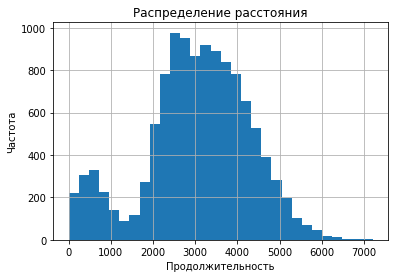

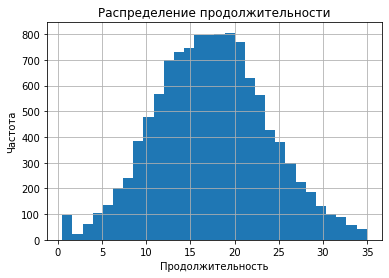

In [25]:
data_free['distance'].hist(bins=30)
plt.title('Распределение расстояния')
plt.xlabel('Продолжительность')
plt.ylabel('Частота')
plt.show()
data_free['duration'].hist(bins=30)
plt.title('Распределение продолжительности')
plt.xlabel('Продолжительность')
plt.ylabel('Частота')
plt.show()

По гистограмме видно, что среднее расстояние для пользователей без подписки составляет от 2000 до 4000 метров. Продолжительность поездки, как и в случае общей выборки, в среднем равно 15-20 минут.

Построим гистограммы распределения расстояния и продолжительности для категории пользователей с подпиской.

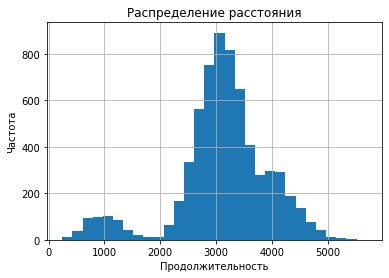

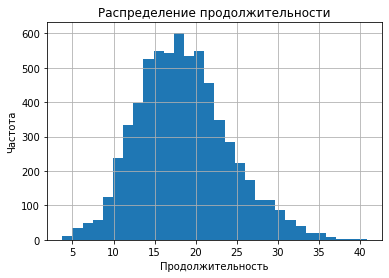

In [26]:
data_ultra['distance'].hist(bins=30)
plt.title('Распределение расстояния')
plt.xlabel('Продолжительность')
plt.ylabel('Частота')
plt.show()
data_ultra['duration'].hist(bins=30)
plt.title('Распределение продолжительности')
plt.xlabel('Продолжительность')
plt.ylabel('Частота')
plt.show()

По гистограмме видно, что среднее расстояние для пользователей с подпиской составляет около 3000 метров. Продолжительность поездки, как и в случае общей выборки, в среднем равно 15-20 минут.

## Подсчёт выручки

Cоздадим датафрейм с агрегированными данными о поездках на основе датафрейма с объединёнными данными из шага 4: найдем суммарное расстояние, количество поездок и суммарное время для каждого пользователя за каждый месяц и сразу добавим тип подписки.

In [29]:
data_total['duration'] = np.ceil(data_total['duration'])
data_total_sum = data_total.pivot_table(index=['user_id', 'month', 'subscription_type'], values=['distance', 'duration'], aggfunc=[np.sum, 'count'])
data_total_sum.columns = ['total_distance', 'total_duration', 'count', 'count_del']
#del data_total_sum['count_del']
#data_total_sum = data_total_sum.reset_index()
data_total_sum.head(10)

total_distance  total_duration  count  \
user_id month subscription_type                                          
1       1     ultra                 7027.511294            42.0      2   
        4     ultra                  754.159807             7.0      1   
        8     ultra                 6723.470560            46.0      2   
        10    ultra                 5809.911100            32.0      2   
        11    ultra                 7003.499363            56.0      3   
        12    ultra                 6751.629942            28.0      2   
2       3     ultra                10187.723006            63.0      3   
        4     ultra                 6164.381824            40.0      2   
        6     ultra                 3255.338202            14.0      1   
        7     ultra                 6780.722964            48.0      2   

                                 count_del  
user_id month subscription_type             
1       1     ultra                      2  
        4     ultra                      1  
        8     ultra                      2  
        10    ultra                      2  
        11    ultra                      3  
        12    ultra                      2  
2       3     ultra                      3  
        4     ultra                      2  
        6     ultra                      1  
        7     ultra                      2

В этот же датафрейм добавим столбец с помесячной выручкой, которую принёс каждый пользователь. 

Для начала создадим функцию для подсчета выручки.

In [28]:
def total_sum(raw):
    user_id = raw[0]
    subs_type = raw[2]
    duration = raw[4]
    count = raw[5]
    if subs_type=='free':
        return 50*count+8*duration
    else:
        return 6*duration+199

Создаем новый столбец с помесячной выручкой и применяем ранее созданную функцию для каждой строки.

In [29]:
data_total_sum['total_income'] = data_total_sum.apply(func = total_sum, axis=1)
data_total_sum.head()

,user_id,month,subscription_type,total_distance,total_duration,count,total_income
0,1,1,ultra,7027.511294,42.0,2,451.0
1,1,4,ultra,754.159807,7.0,1,241.0
2,1,8,ultra,6723.470560,46.0,2,475.0
3,1,10,ultra,5809.911100,32.0,2,391.0
4,1,11,ultra,7003.499363,56.0,3,535.0


Все корректно.

### Проверка гипотез

Зададим уровень значимости для проверок наших гипотез в 5%.

In [30]:
alpha = 0.05

### Тратят ли пользователи с подпиской больше времени на поездки?

Для проверки этой гипотезы используем двухвыборочный правосторонний t-тест для независимых выборок. Нулевая гипотеза - выборочные средние времени поездки двух выборок примерно равны, альтернативная гипотеза - выборочное среднее времени поездки для пользователей с подпиской заметно отличается от пользователей без подписки в большую сторону.

In [31]:
results_1 = st.ttest_ind(data_ultra['duration'], data_free['duration'], alternative='greater')
if alpha>results_1.pvalue:
    print('Отвергаем нулевую гипотезу')
else:
    print('Не отвергаем нулевую гипотезу')
results_1.pvalue

Отвергаем нулевую гипотезу


1.2804098316645618e-34

Нулевая гипотеза опровергнута, а значит, делаем вывод о том, что пользователи с подпиской тратят действительно больше времени на поездки. Стоит сказать, что даже при уровне значимости в 1% не изменилась бы ситуация, pvalue очень мал.

### Расстояние одной поездки в 3130 метров — оптимальное с точки зрения износа самоката. Можно ли сказать, что среднее расстояние, которое проезжают пользователи с подпиской за одну поездку, не превышает 3130 метров? 

Для проверки этой гипотезы используем одновыборочный правосторонний t-тест. Нулевая гипотеза - выборочное среднее расстояние одной поездки равно примерно 3130 (или меньше). Альтернативная гипотеза - выборочное среднее превышает 3130 метров.

In [32]:
value = 3130
results_2 = st.ttest_1samp(data_ultra['distance'], value, alternative='greater')
if alpha>results_2.pvalue:
    print('Отвергаем нулевую гипотезу')
else:
    print('Не отвергаем нулевую гипотезу')
results_2.pvalue

Не отвергаем нулевую гипотезу


0.9195368847849785

Нулевая гипотеза не опровергнута, а значит, делаем вывод о том, что пользователи с подпиской не превышают среднее расстояние в 3130 метров за одну поездку, pvalue очень велик.

### Будет ли помесячная выручка от пользователей с подпиской по месяцам выше, чем выручка от пользователей без подписки?

Для проверки этой гипотезы используем двухвыборочный правосторонний t-тест для независимых выборок. Нулевая гипотеза - выборочные средние выручки двух выборок примерно равны, альтернативная гипотеза - выборочное среднее выручки для пользователей с подпиской заметно отличается от пользователей без подписки в большую сторону.

In [33]:
results_3 = st.ttest_ind(data_total_sum.loc[data_total_sum['subscription_type']=='ultra', 'total_income'], 
                         data_total_sum.loc[data_total_sum['subscription_type']=='free', 'total_income'], 
                         alternative='greater')
print(results_3.pvalue)
if alpha>results_3.pvalue:
    print('Отвергаем нулевую гипотезу')
else:
    print('Не отвергаем нулевую гипотезу')

1.8850394384715216e-31
Отвергаем нулевую гипотезу


Нулевая гипотеза опровергнута, а значит, делаем вывод о том, что пользователи с подпиской приносят действительно больше ежемесячной выручки чем пользователи без подписки. Стоит сказать, что даже при уровне значимости в 1% не изменилась бы ситуация, pvalue очень мал.

**ВЫВОД:** 
- пользователи с подпиской тратят больше времени на поездки
- среднее расстояние, которое проезжают пользователи с подпиской за одну поездку, не превышает 3130 метров
- помесячная выручка от пользователей с подпиской по месяцам выше, чем выручка от пользователей без подписки

## Распределения

### Задача 1

Отделу маркетинга GoFast поставили задачу: нужно провести акцию с раздачей промокодов на один бесплатный месяц подписки, в рамках которой как минимум **100** существующих клиентов должны продлить эту подписку. То есть по завершении периода действия подписки пользователь может либо отказаться от неё, либо продлить, совершив соответствующий платёж. Эта акция уже проводилась ранее и по итогу выяснилось, что после бесплатного пробного периода подписку продлевают **10%** пользователей. Выясните, какое минимальное количество промокодов нужно разослать, чтобы вероятность не выполнить план была примерно **5%**. Подберите параметры распределения, описывающего эту ситуацию, постройте график распределения и сформулируйте ответ на вопрос о количестве промокодов.

Зададим первоначальные значения - min_value это вероятность не выполнить план, k это количество клиентов, которые должны продлить эту подписку, lmbd - интенсивность продления подписки для распределения Пуассона.

In [34]:
min_value = 0.05
k = 100
for lmbd in range(10, 200, 1):
    current_value = st.poisson.cdf(k-1, lmbd)
    if 0.045<=current_value<=0.055:
        print(current_value, lmbd)
        break
print('Минимальное количество промокодов равно', lmbd/0.1)

0.049973377638439065 117
Минимальное количество промокодов равно 1170.0


**Решение:** логика такова, что нам нужно найти такую интенсивность, чтобы она удовлетворяла нашему условию. Через распределения Пуассона будем находить такую вероятность, что при данной интенсивность процент того, что как минимум 100 клиентов не продлят прописку, будет в районе 5%. Строка кода st.poisson.cdf(k-1, lmbd) показывает вероятность левого хвоста распределения, то есть суммарную вероятность того, что мы получим до 99 продлений подписок включительно (план не выполнен). Как видим, при интенсивности в 117 мы получили почти 5% вероятность того, что план не будет выполнен. Поскольку подписку продлевают примерно 10% пользователей в месяц, то минимальное количество промокодов для поставленной задачи равно интенсивность/0.01. В итоге получаем, что мы должны разослать как минимум **11700** промокодов.

Построим график распределения.

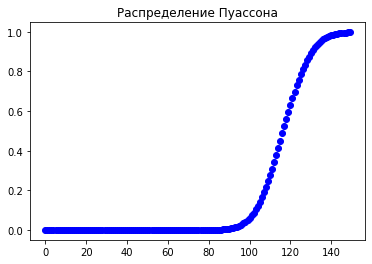

In [35]:
distr = []
for i in range(150):
    distr.append(st.poisson.cdf(i, lmbd))
plt.plot(range(150), distr, 'bo')
plt.title('Распределение Пуассона')
plt.show()

P.S. Я только потом увидел подсказку, что задачу надо было решать через биномиальное распределение, а не через Пуассона, но я в итоге применил аппроксимацию биномиального распределения распределением Пуассона, кажется, тут оно уместно из-за небольшой вероятности p=0.1 и большого n=lmbd/p=117/0.1=1170.

### Задача 2

Отдел маркетинга рассылает клиентам push-уведомления в мобильном приложении. Клиенты могут открыть его или не открывать. Известно, что уведомления открывают около 40% получивших клиентов. Отдел планирует разослать 1 млн уведомлений. С помощью аппроксимации постройте примерный график распределения и оцените вероятность того, что уведомление откроют не более 399,5 тыс. пользователей.

Построим распределение для заданных данных и найдем вероятность левого хвоста для данного распределения.

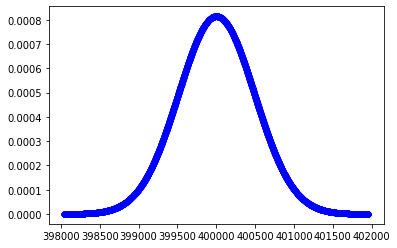

Уведомление откроют не более 399,5 тыс. пользователей с вероятностью 15.4 %


In [36]:
# задаём параметры биномиального распределения
n = 10**6
p = 0.4

# границы промежутка, в котором будем строить аппроксимацию -
# от n*p минус 4 ст.отклонения бином.распределения
# до n*p плюс 4 ст.отклонения бином.распределения
# (там, где вероятности значений почти не равны нулю)
left = int(n * p - 4 * sqrt(n * p * (1 - p)))
right = int(n * p + 4 * sqrt(n * p * (1 - p)))
 
# зададим набор значений биномиальной величины на выбранном промежутке:
# все неотрицательные целые числа от left до right
x = list(range(max(0, left), right))
# рисуем график биномиального распределения
ax = plt.subplot()
# используем синие о-образные маркеры и размер маркера 5
ax.plot(x, st.binom.pmf(x, n, p), 'bo', ms=5,
	      label='вероятности биномиального распределения')
plt.show()
print('Уведомление откроют не более 399,5 тыс. пользователей с вероятностью', round(st.binom.cdf(399500, n, p), 3)*100, '%')

Распределение действительно выглядит нормальным, а вероятность, с которой уведомление откроют не более 399.5 тысяч пользователей равна 15.4%.

## Результаты работы и выводы

**В результате работы мы сделали следующее:**
1. Изучили и предобработали данные
2. Провели исследовательских анализ данных
3. Объединили таблицы и получили общий датафрейм
4. Посчитали ежемесячную выручку
5. Проверили несколько гипотез

**Получили следующие выводы:**
1. При обработке данных не было обнаружено пропусков, это хороший знак, что техническая часть сбора информации работает корректно. Однако **были обнаружены дубликаты** в табличке с уникальными номерами пользователей, можно сообщить об этом разработчику, скорее всего, в базе данных хранятся дубликаты пользователей, надо их удалять, ведь они занимают лишнее место.
2. При обработке мы встретились с аномальными минимальными значениями пройденного расстояния и времени. Но их можно объяснять тем, что клиент арендовал самокат и сразу завершил поездку, отсюда и практически нулевые значения времени и расстояния. Мы избавились от них во избежании выбросов для корректности нашего дальнейшего исследования.
3. При исследовательском анализе данных мы пришли к следующим выводам: 
- Больше всего пользователей в Пятигорске, меньше всего в Москве
- **Количество пользователей без подписки выше**, но разница невысокая
- Наибольшее количество пользователей в районе **23-27 лет** 
- **Расстояние** в среднем за одну поездку равно **3000 метров**
- В среднем **продолжительность** за одну поездку равна **15-20 минут**
4. При проверке гипотез мы пришли к следующим выводам:
- **пользователи с подпиской** тратят больше времени на поездки, а значит, они **могут более выгодны** для компании
- **среднее расстояние**, которое проезжают пользователи с подпиской за одну поездку, **не превышает 3130 метров**. Это **оптимально** с точки зрения износа самоката 
- помесячная **выручка от пользователей с подпиской по месяцам выше**, чем выручка от пользователей без подписки

**Общий вывод:** изучив данные и гипотезы мы пришли к общему выводу, что **пользователи с подпиской выгоднее для компании**, чем без. Согласно нашей выборке мы имеем около **55% пользователей без подписки и 45% с подпиской**. Если в генеральной совокупности такая же доля пользователей с подпиской или без, то можно сказать, что пользователи достаточно охотно покупают подписку, ведь 45% это почти половина! **Условия подписки можно сохранить**, раз их покупает почти половина, а больше внимания направить на привлечение новых пользователей, которые будут покупать подписку. Это можно сделать например посредством увеличения тарифов в бесплатной подписке, чтобы пользователи стремились покупать платную подписку, правда надо это делать аккуратно, с определенной индексацией цен, чтобы не пугать ценами новых пользователей. Второй вариант это **распространение промокодов**, чтобы в дальнейшем пользователи продлили подписку, но и тут надо действовать осторожно, чтобы не переборщить с количеством промокодов, ведь это может снизить прибыль. Так, в дополнительной задаче мы выяснили, чтобы привлечь минимум 100 пользователей, которые продлят подписку с вероятностью в 95%, нам нужно выдать минимум 11700 промокодов.